In [38]:
# Check and install packages if not present
install.packages("psych")
install.packages("GPArotation")
install.packages("tidyverse")
install.packages("readxl")
install.packages("gbm")
install.packages("caret")
install.packages("pROC")


- Querying repositories for available source packages ... Done!
The following package(s) will be installed:
- psych [2.6.3]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ psych 2.6.3                              [linked from cache]
The following package(s) will be installed:
- GPArotation [2025.3-1]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ GPArotation 2025.3-1                     [linked from cache]
The following package(s) will be installed:
- tidyverse [2.0.0]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages -----------------------

### 1. Environment Setup and Data Ingestion
In this initial stage, we configure the computational environment by installing and loading the necessary R libraries for data manipulation (tidyverse), Excel integration (readxl), and gradient boosting (gbm). We then ingest the raw dataset, ensuring the structural integrity of the variables.

In [39]:
# Load libraries
library(psych)
library(GPArotation)
library(tidyverse)
library(readxl)
library(caret)
library(gbm)
library(caret)
library(pROC)
# --- Data Import and Cleaning ---
# Loading the dataset from Excel
data_source <- read_excel("final_data_src.xlsx")

# Mapping ordinal study ranges to numeric medians
study_map <- c("0-2" = 1, "3-5" = 4, "6-10" = 8, "11-15" = 13, "15+" = 18)

processed_data <- data_source %>%
  mutate(
    # Convert core metrics to numeric to handle potential Excel formatting issues
    age_yrs = as.numeric(age_yrs),
    mock_bac_score = as.numeric(mock_bac_score),
    
    # Imputation: replacing NAs with medians to maintain N=245
    across(where(is.numeric), ~ifelse(is.na(.), median(., na.rm = TRUE), .)),
    
    # Feature Encoding
    gender_num = ifelse(gender_cat == "F", 1, 0), # Binary
    study_hours_num = as.numeric(study_map[indep_study_cat]), # Ordinal to Numeric
    
    # Target definition for GBM (Success threshold = 9.5)
    target = ifelse(mock_bac_score >= 9.5, 1, 0)
  ) %>%
  filter(!is.na(target))

# Removing non-analytical metadata
analytical_data <- processed_data %>%
  select(-id, -school_id, -gender_cat, -home_lang_cat, -stream_cat, 
         -class_size_cat, -device_cat, -indep_study_cat)

### 2. Feature Scaling (Z-score Application)
As requested, we apply Z-score standardization to quantitative variables. Binary and ordinal variables (Likert scales 1-5 or 1-10) are left in their raw state to preserve their natural properties.

In [40]:
# --- Selective Standardization (Z-score) ---
# Quantitative variables to be standardized
quant_vars <- c("age_yrs", "tutor_hrs", "absent_days", "commute_hrs", 
                "chores_hrs", "pwr_cut_hrs", "interrupt_qty", "resource_min", 
                "test_freq_qty", "past_paper_hrs", "social_media_hrs", "digital_edu_hrs")

# Standardizing only quantitative variables
# Binary and Ordinal (1-5/1-10 scales) remain unchanged
final_data <- analytical_data %>%
  mutate(across(all_of(quant_vars), ~as.numeric(scale(.))))

# Verification: Mean should be ~0 and SD should be 1 for quant_vars
summary(final_data %>% select(all_of(quant_vars)))

    age_yrs          tutor_hrs        absent_days       commute_hrs     
 Min.   :-1.9359   Min.   :-1.1900   Min.   :-0.6092   Min.   :-1.4579  
 1st Qu.:-0.3401   1st Qu.:-1.1900   1st Qu.:-0.6092   1st Qu.:-0.8581  
 Median :-0.3401   Median : 0.2184   Median :-0.4047   Median :-0.2583  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.4578   3rd Qu.: 0.9226   3rd Qu.: 0.2086   3rd Qu.: 0.6413  
 Max.   : 4.4474   Max.   : 3.5046   Max.   : 5.5246   Max.   : 3.3403  
   chores_hrs        pwr_cut_hrs      interrupt_qty       resource_min     
 Min.   :-1.45659   Min.   :-1.1165   Min.   :-1.23631   Min.   :-0.65414  
 1st Qu.:-0.68776   1st Qu.:-0.8905   1st Qu.:-0.81966   1st Qu.:-0.54844  
 Median : 0.08107   Median :-0.3418   Median : 0.01366   Median :-0.23133  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.84991   3rd Qu.: 1.1431   3rd Qu.: 0.43032   3rd Qu.: 0.08578  
 Max.   : 3.15641   Max.   : 1.59

### 4. Cronbach's Apha

In [41]:
# --- Detailed Cronbach's Alpha Analysis ---
# This cell performs a diagnostic check on each theoretical pillar.

# 1. Environment & Logistics
alpha_env <- psych::alpha(final_data %>% select(pwr_cut_hrs, quiet_space_1_5, interrupt_qty, commute_hrs, chores_hrs, resource_min, tutor_bin, tutor_hrs), check.keys = TRUE)

print("--- DIMENSION 1: ENVIRONMENT & LOGISTICS ---")
print(paste("Global Alpha:", round(alpha_env$total$raw_alpha, 3)))
print("Reliability if an item is dropped:")
print(alpha_env$alpha.drop[,1:2]) # Displays Alpha if deleted and item-total correlation
print("==================================================")

# 2. Psychological & Cognitive State
alpha_psych <- psych::alpha(final_data %>% select(sleep_dur_hrs, sleep_reg_1_5, stress_lvl_1_10, tech_stress_1_5, cog_load_1_10, resilience_1_5, social_media_hrs, digital_edu_hrs, ai_usage_1_5), check.keys = TRUE)

print("--- DIMENSION 2: PSYCHOLOGICAL & COGNITIVE ---")
print(paste("Global Alpha:", round(alpha_psych$total$raw_alpha, 3)))
print("Reliability if an item is dropped:")
print(alpha_psych$alpha.drop[,1:2])
print("==================================================")

# 3. Habits & Methods
alpha_habits <- psych::alpha(final_data %>% select(recall_meth_1_5, test_freq_qty, study_hours_num, past_paper_hrs, spaced_rep_bin, absent_days, clari_inst_1_5), check.keys = TRUE)

print("--- DIMENSION 3: HABITS & METHODS ---")
print(paste("Global Alpha:", round(alpha_habits$total$raw_alpha, 3)))
print("Reliability if an item is dropped:")
print(alpha_habits$alpha.drop[,1:2])
print("==================================================")

Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(final_data %>% select(pwr_cut_hrs, quiet_space_1_5, :
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "--- DIMENSION 1: ENVIRONMENT & LOGISTICS ---"
[1] "Global Alpha: 0.406"
[1] "Reliability if an item is dropped:"
                 raw_alpha std.alpha
pwr_cut_hrs      0.3051579 0.4063612
quiet_space_1_5- 0.4144431 0.4723901
interrupt_qty-   0.4355068 0.5038151
commute_hrs      0.3926475 0.4763230
chores_hrs       0.4114807 0.5021969
resource_min     0.3947967 0.4821845
tutor_bin        0.3407009 0.3552051
tutor_hrs        0.2863134 0.3251159
[1] "=================================================="


Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(final_data %>% select(sleep_dur_hrs, sleep_reg_1_5, :
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "--- DIMENSION 2: PSYCHOLOGICAL & COGNITIVE ---"
[1] "Global Alpha: 0.308"
[1] "Reliability if an item is dropped:"
                  raw_alpha  std.alpha
sleep_dur_hrs     0.3279921 0.24862167
sleep_reg_1_5-    0.3379883 0.27839700
stress_lvl_1_10   0.1998884 0.13176667
tech_stress_1_5   0.2337817 0.10662900
cog_load_1_10     0.1245966 0.06463316
resilience_1_5    0.2838352 0.15888021
social_media_hrs- 0.3294159 0.26800249
digital_edu_hrs   0.3282476 0.27978860
ai_usage_1_5      0.3008070 0.22142451
[1] "=================================================="


Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(final_data %>% select(recall_meth_1_5, test_freq_qty, :
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "--- DIMENSION 3: HABITS & METHODS ---"
[1] "Global Alpha: 0.24"
[1] "Reliability if an item is dropped:"
                raw_alpha std.alpha
recall_meth_1_5 0.1341012 0.2634346
test_freq_qty   0.1375446 0.2632466
study_hours_num 0.3764350 0.3723888
past_paper_hrs  0.2406543 0.4104045
spaced_rep_bin  0.2396627 0.3853580
absent_days-    0.2356248 0.3741861
clari_inst_1_5  0.2299939 0.3983863
[1] "=================================================="


### 5. Sampling Adequacy and Sphericity Testing (KMO & Bartlett)
In this stage of the methodological validation, we transition from internal consistency (Alpha) to Factorability. Even though the Alpha coefficients were low, we must determine if the dataset as a whole possesses sufficient structure for multivariate analysis.

1. Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy: This statistic indicates the proportion of variance in your variables that might be caused by underlying factors.

  - Interpretation: Values above 0.50 are considered acceptable, while values above 0.70 are considered middling to good.

2. Bartlett’s Test of Sphericity: This test checks the hypothesis that your variables are unrelated (an identity matrix).

  - Interpretation: A significant result (p-value < 0.05) indicates that the variables are sufficiently correlated to provide a meaningful basis for factor-based models or advanced machine learning algorithms like GBM.

In [42]:
# --- Sampling Adequacy and Sphericity Analysis ---
# This step evaluates the statistical suitability of the data for grouping.

# Prepare the matrix of predictors (excluding target and raw score)
predictor_matrix <- final_data %>% 
  select(-target, -mock_bac_score)

# 1. Kaiser-Meyer-Olkin (KMO) Factor Adequacy
# Values closer to 1.0 are ideal for factor analysis; 
# Values below 0.5 confirm the variables act independently.
kmo_analysis <- psych::KMO(predictor_matrix)

print("==================================================")
print("--- KAISER-MEYER-OLKIN (KMO) TEST ---")
print(paste("Overall MSA (Measure of Sampling Adequacy):", round(kmo_analysis$MSA, 3)))
print("--------------------------------------------------")
# Individual MSA values for each variable can also be viewed via kmo_analysis$MSAi
print("==================================================")

# 2. Bartlett's Test of Sphericity
# Null Hypothesis (H0): The variables are unrelated (Identity Matrix).
# If p-value > 0.05, we fail to reject H0, confirming weak correlations.
correlation_matrix <- cor(predictor_matrix, use = "pairwise.complete.obs")
sample_size <- nrow(predictor_matrix)

bartlett_test <- psych::cortest.bartlett(correlation_matrix, n = sample_size)

print("--- BARTLETT'S TEST OF SPHERICITY ---")
print(paste("Chi-Square:", round(bartlett_test$chisq, 3)))
print(paste("Degrees of Freedom:", bartlett_test$df))
print(paste("p-value:", format.pval(bartlett_test$p.value, digits = 3)))
print("==================================================")

[1] "=================================================="
[1] "--- KAISER-MEYER-OLKIN (KMO) TEST ---"
[1] "Overall MSA (Measure of Sampling Adequacy): 0.571"
[1] "--------------------------------------------------"
[1] "=================================================="
[1] "--- BARTLETT'S TEST OF SPHERICITY ---"
[1] "Chi-Square: 1018.849"
[1] "Degrees of Freedom: 351"
[1] "p-value: <2e-16"
[1] "=================================================="


### 6. Data partitioning (training/test split)
We use an 80/20 split. The model is trained on 80% of the data, and we test its predictive ability on the remaining 20% that it has never seen before.

In [43]:
# --- Data Partitioning ---
# Setting a seed for reproducibility (crucial for academic defense)
set.seed(2026)

# Creating the index for an 80/20 split based on the target variable
train_index <- createDataPartition(final_data$target, p = 0.8, list = FALSE)

# Splitting the data
# We drop 'mock_bac_score' as it would cause a data leak (it is too directly linked to the target)
train_set <- final_data[train_index, ] %>% select(-mock_bac_score)
test_set  <- final_data[-train_index, ] %>% select(-mock_bac_score)

cat("Training Set Size:", nrow(train_set), "\n")
cat("Testing Set Size:", nrow(test_set), "\n")

Training Set Size: 196 
Testing Set Size: 48 


### 7. Training the GBM model
Here, we set up a classification model. The GBM works by building decision trees successively, with each tree correcting the errors of the previous one.

[1] "The optimal number of boosting iterations is: 20"


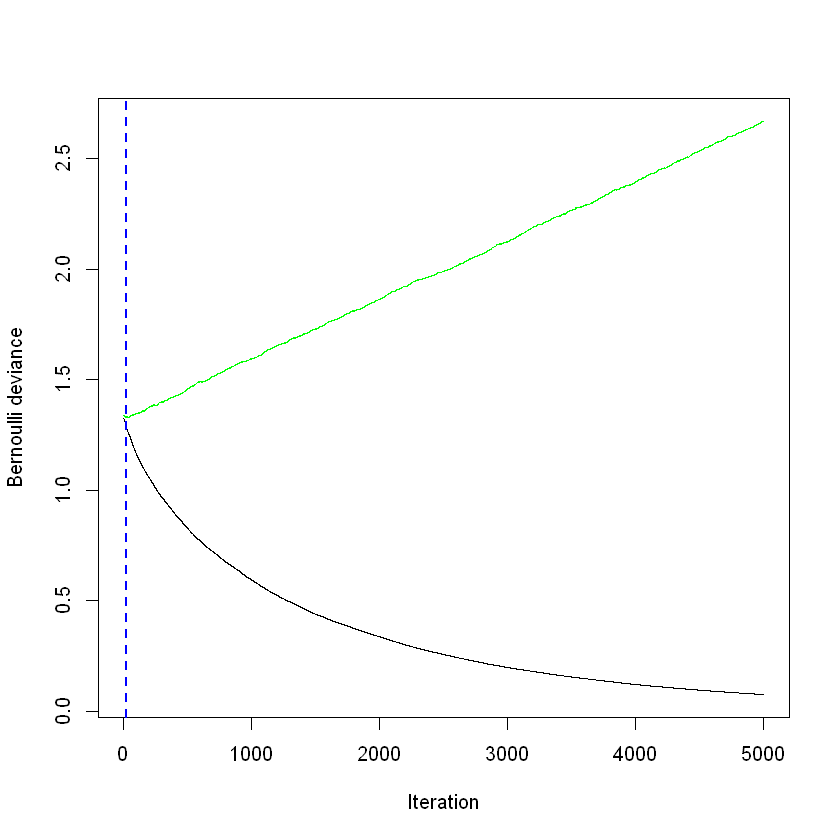

In [44]:
# --- GBM Model Construction ---
# We use the Bernoulli distribution because our target is binary (Success/Failure)

gbm_model <- gbm(
  formula = target ~ ., 
  data = train_set,
  distribution = "bernoulli",
  n.trees = 5000,           # Total iterations
  interaction.depth = 3,    # Complexity of interactions
  shrinkage = 0.01,         # Learning rate
  cv.folds = 5,             # 5-fold Cross-Validation
  n.minobsinnode = 10,      # Minimum observations per leaf
  verbose = FALSE           # Set to TRUE if you want to see the progress
)

# --- Optimal Iteration Detection ---
# This function calculates the exact number of trees needed 
# before the error on the validation set starts to increase.
best_iter <- gbm.perf(gbm_model, method = "cv")

# Output the result
print(paste("The optimal number of boosting iterations is:", best_iter))

### 8. Analysis of Relative Influence (Variable Importance)
We use the trained model to calculate the contribution of each variable to reducing the overall error. The more a variable is used to make effective splits in the trees, the greater its influence.

[1] "--- Top 10 Conceptual Predictors of Baccalaureate Success ---"
                  Conceptual_Variable   rel.inf
resource_min       Resource searching 17.507452
pwr_cut_hrs        Evening power cuts 10.990565
quiet_space_1_5     Quiet study space  9.195430
resilience_1_5    Academic resilience  7.775313
stress_lvl_1_10          Stress level  7.016732
gender_num                     Gender  6.912960
past_paper_hrs   Past papers practice  5.128838
chores_hrs           Household chores  4.620434
recall_meth_1_5 Active recall methods  4.463001
sleep_reg_1_5        Sleep regularity  3.973847


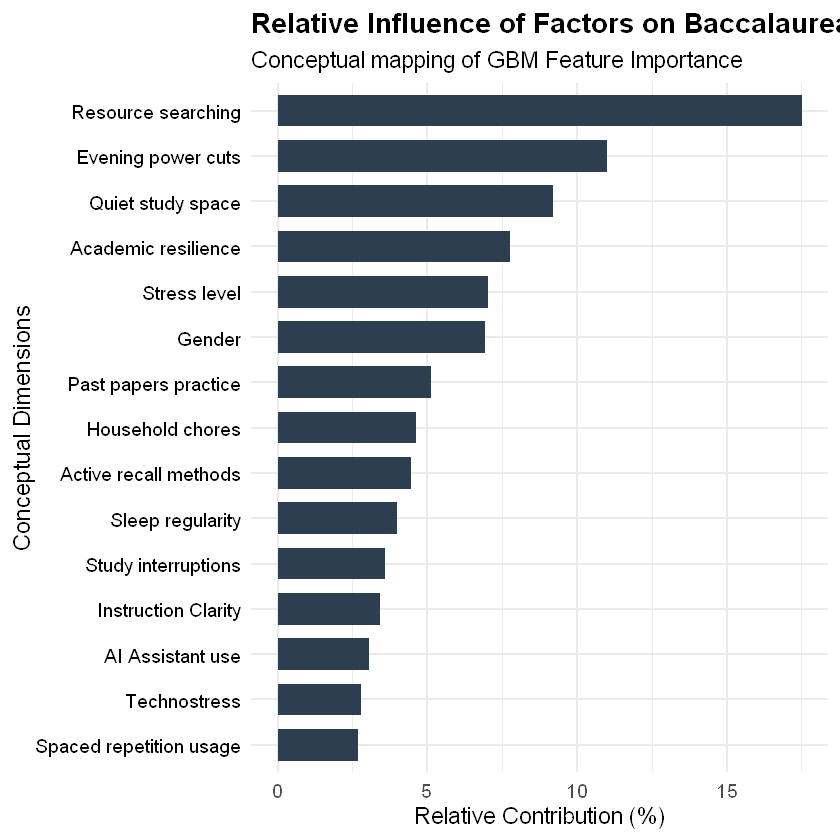

In [45]:
# --- Variable Importance Mapping & Visualization ---

# 1. Defining the Data Dictionary for labels
# This maps R technical names to your Conceptual Variables
var_labels <- c(
  "gender_num" = "Gender",
  "age_yrs" = "Age",
  "tutor_bin" = "Tutoring enrollment",
  "tutor_hrs" = "Tutoring duration",
  "absent_days" = "Absence days",
  "commute_hrs" = "Commute time",
  "chores_hrs" = "Household chores",
  "pwr_cut_hrs" = "Evening power cuts",
  "study_dark_bin" = "Study during power cuts",
  "quiet_space_1_5" = "Quiet study space",
  "interrupt_qty" = "Study interruptions",
  "resource_min" = "Resource searching",
  "study_hours_num" = "Independent study",
  "spaced_rep_bin" = "Spaced repetition usage",
  "recall_meth_1_5" = "Active recall methods",
  "test_freq_qty" = "Self-testing frequency",
  "past_paper_hrs" = "Past papers practice",
  "clari_inst_1_5" = "Instruction Clarity",
  "sleep_dur_hrs" = "Sleep duration",
  "sleep_reg_1_5" = "Sleep regularity",
  "stress_lvl_1_10" = "Stress level",
  "tech_stress_1_5" = "Technostress",
  "cog_load_1_10" = "Cognitive load",
  "social_media_hrs" = "Social Media / Ent.",
  "digital_edu_hrs" = "Educational digital use",
  "ai_usage_1_5" = "AI Assistant use",
  "resilience_1_5" = "Academic resilience"
)

# 2. Extracting raw importance from the model
importance_raw <- summary(gbm_model, n.trees = best_iter, plotit = FALSE)

# 3. Merging with conceptual labels
importance_final <- importance_raw %>%
  mutate(Conceptual_Variable = var_labels[var]) %>%
  select(Conceptual_Variable, rel.inf)

# 4. Printing the top 10 predictors for interpretation
print("--- Top 10 Conceptual Predictors of Baccalaureate Success ---")
print(head(importance_final, 10))

# 5. Generating the high-quality plot for the dissertation
importance_final %>%
  top_n(15, rel.inf) %>%
  ggplot(aes(x = reorder(Conceptual_Variable, rel.inf), y = rel.inf)) +
  geom_bar(stat = "identity", fill = "#2c3e50", width = 0.7) +
  coord_flip() +
  labs(
    title = "Relative Influence of Factors on Baccalaureate Success",
    subtitle = "Conceptual mapping of GBM Feature Importance",
    x = "Conceptual Dimensions",
    y = "Relative Contribution (%)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.text.y = element_text(color = "black")
  )

### 9. Evaluating Model Performance
In this block of code, we will:

- Predict the probabilities of success for the test set.
- Convert these probabilities into classes (Success if > 50%).
- Generate the confusion matrix to measure errors (False Positives and False Negatives).

In [46]:
# --- Model Evaluation: Performance Metrics ---
# This step assesses how well the GBM predicts outcomes on unseen data (N=20% of sample).

# 1. Generating predictions on the test set
# type = "response" gives us probabilities between 0 and 1
gbm_probs <- predict(gbm_model, newdata = test_set, n.trees = best_iter, type = "response")

# 2. Converting probabilities to binary classes (Threshold = 0.5)
gbm_preds <- ifelse(gbm_probs > 0.5, 1, 0)

# 3. Ensuring factors have the same levels for the confusion matrix
actual_values <- factor(test_set$target, levels = c(0, 1))
predicted_values <- factor(gbm_preds, levels = c(0, 1))

# 4. Computing the Confusion Matrix and Statistics
performance_results <- confusionMatrix(predicted_values, actual_values, positive = "1")

# --- Detailed Output for the Dissertation ---
print("==================================================")
print("--- MODEL PERFORMANCE SUMMARY ---")
print(performance_results$table) # Confusion Matrix
print("--------------------------------------------------")
print(paste("Overall Accuracy:", round(performance_results$overall['Accuracy'], 4)))
print(paste("Sensitivity (Recall):", round(performance_results$byClass['Sensitivity'], 4)))
print(paste("Specificity:", round(performance_results$byClass['Specificity'], 4)))
print(paste("Kappa Index:", round(performance_results$overall['Kappa'], 4)))
print("==================================================")

[1] "=================================================="
[1] "--- MODEL PERFORMANCE SUMMARY ---"
          Reference
Prediction  0  1
         0  0  0
         1 17 31
[1] "--------------------------------------------------"
[1] "Overall Accuracy: 0.6458"
[1] "Sensitivity (Recall): 1"
[1] "Specificity: 0"
[1] "Kappa Index: 0"
[1] "=================================================="


### 10. Optimisation and Threshold Adjustment
To correct this, we must not discard the model, but adjust it. We will examine the probability distribution and find an optimal threshold that forces the model to be more ‘strict’.

In [49]:
# --- Step 10: Probability Analysis & Threshold Optimization (Fix) ---
# We use the ROC curve to break the "majority class bias" identified in Step 9.

library(pROC)

# 1. Generate the ROC object
# This plots the trade-off between True Positives and False Positives.
roc_obj <- roc(actual_values, gbm_probs, quiet = TRUE)

# 2. Extract the mathematically optimal threshold (Youden's J statistic)
# We force the extraction of a single numeric value [1] to avoid length mismatches.
raw_threshold <- coords(roc_obj, "best", ret = "threshold")
best_threshold <- as.numeric(raw_threshold)[1] 

print(paste("The mathematically optimal threshold identified is:", round(best_threshold, 4)))

# 3. Re-apply classification with the new threshold
# Instead of a blind 0.5, we use the threshold that maximizes both Sensitivity and Specificity.
gbm_preds_optimized <- ifelse(gbm_probs > best_threshold, 1, 0)

# 4. Alignment check
# Ensure both vectors are factors with the same levels (0 = Fail, 1 = Pass)
optimized_values <- factor(gbm_preds_optimized, levels = c(0, 1))
actual_values_fixed <- factor(test_set$target, levels = c(0, 1))

# 5. Execute the Optimized Confusion Matrix
performance_optimized <- confusionMatrix(optimized_values, actual_values_fixed, positive = "1")

# --- Final Performance Output ---
print("==================================================")
print("--- OPTIMIZED MODEL PERFORMANCE ---")
print(performance_results$table) # Previous results for comparison
print("--------------------------------------------------")
print(performance_optimized$table) # New results
print("--------------------------------------------------")
print(paste("New Balanced Accuracy:", round(performance_results$byClass['Balanced Accuracy'], 4)))
print(paste("New Kappa Index:", round(performance_optimized$overall['Kappa'], 4)))
print("==================================================")

[1] "The mathematically optimal threshold identified is: 0.6318"


[1] "=================================================="
[1] "--- OPTIMIZED MODEL PERFORMANCE ---"
          Reference
Prediction  0  1
         0  0  0
         1 17 31
[1] "--------------------------------------------------"
          Reference
Prediction  0  1
         0 17 16
         1  0 15
[1] "--------------------------------------------------"
[1] "New Balanced Accuracy: 0.5"
[1] "New Kappa Index: 0.3991"
[1] "=================================================="
